# 実験: Curve Direction v2 比較検証

本ノートブックでは、カーブ方向予測における2つのプーリング戦略を比較します。

1. **Model A (Adjacent)**: 隣接限月差分 ($C_1 \dots C_7$) の7系列をプーリング。
2. **Model B (AllPair)**: 全限月ペア ($M_i - M_j$) の28系列をプーリング。

## 評価指標
- **Global IC**: 時系列的な予測の正確さ（Spearman相関）。
- **Direction Accuracy**: 方向（プラス/マイナス）の的中率。

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

from src.processing import load_and_clean_data
from src.features_rv import generate_rv_features
from src.features import frac_diff
from src.pooling_curve import pool_curve_data
from src.modeling import walk_forward_validation, summarize_ic

START_DATE = '2024-01-01'
print(f'Start Date: {START_DATE}')

Start Date: 2024-01-01


In [2]:
def build_allpair_df(df):
    records = []
    pair_info = {}
    common_cols = [
        'Date', 'Days_to_MPM', 'Actual_Policy_Rate', 'is_post_mpm',
        'C1_frac_diff', 'C2_frac_diff', 'C3_frac_diff', 'C4_frac_diff',
        'C5_frac_diff', 'C6_frac_diff', 'C7_frac_diff',
        'M1_spread', 'M1_frac_diff', 'M1_is_imputed', 'M2_is_imputed', 'M3_is_imputed', 
        'M4_is_imputed', 'M5_is_imputed', 'M6_is_imputed', 'M7_is_imputed', 'M8_is_imputed',
        'USDJPY_frac_diff', 'JGB_Future_frac_diff', 'Nikkei225_frac_diff', 'DXY_frac_diff'
    ]
    pair_id = 0
    for i, j in combinations(range(1, 9), 2):
        span_col = f'Span_{i}_{j}'
        df[span_col] = df[f'M{i}_spread'] - df[f'M{j}_spread']
        df[f'{span_col}_fd'] = frac_diff(df[span_col], d=0.4, window=50)
        tmp = df[common_cols + [span_col, f'{span_col}_fd']].copy()
        tmp['Span_Level'] = tmp[span_col]
        tmp['Span_frac_diff'] = tmp[f'{span_col}_fd']
        tmp['Leg_Near'], tmp['Leg_Far'], tmp['Meeting_Index'] = i, j, pair_id
        tmp['Pair_Label'] = f'M{i}M{j}'
        records.append(tmp.drop(columns=[span_col, f'{span_col}_fd']))
        pair_info[pair_id] = (i, j)
        pair_id += 1
    pooled = pd.concat(records, ignore_index=True)
    for h in [3, 5]:
        pooled[f'Target_{h}d'] = pooled.groupby('Pair_Label')['Span_Level'].shift(-h) - pooled['Span_Level']
        std_vals = pooled.groupby('Pair_Label')[f'Target_{h}d'].transform('std')
        pooled[f'Target_{h}d_std'] = std_vals
        pooled[f'Target_{h}d_norm'] = pooled[f'Target_{h}d'] / std_vals
    return pooled.drop(columns=['Pair_Label']), pair_info

df_raw = load_and_clean_data('../data/BOJ_data.xlsx', '../data/BOJ_meeting_history.csv')
df_feat = generate_rv_features(df_raw)
df_curve = pool_curve_data(df_feat)
df_allpair, pair_info = build_allpair_df(df_feat.copy())

In [3]:
res_a_3d = walk_forward_validation(df_curve, 'Target_3d_norm', START_DATE)
res_a_5d = walk_forward_validation(df_curve, 'Target_5d_norm', START_DATE)
std_map_3d = df_curve.groupby('Meeting_Index')['Target_3d_std'].first().to_dict()
std_map_5d = df_curve.groupby('Meeting_Index')['Target_5d_std'].first().to_dict()

res_b_3d = walk_forward_validation(df_allpair, 'Target_3d_norm', START_DATE)
res_b_5d = walk_forward_validation(df_allpair, 'Target_5d_norm', START_DATE)

In [4]:
def extract_span_a(results, std_map, near, far):
    p_sum, a_sum = None, None
    for n in range(near, far):
        sub = results[results['Meeting_Index'] == n].set_index('Date')
        std = std_map.get(n, 1.0)
        p, a = sub['Pred'] * std, sub['Actual'] * std
        p_sum = p if p_sum is None else p_sum + p
        a_sum = a if a_sum is None else a_sum + a
    return pd.DataFrame({'Pred': p_sum, 'Actual': a_sum}).dropna()

def get_metrics(pred, actual):
    valid = pd.DataFrame({'p': pred, 'a': actual}).dropna()
    if len(valid) < 2: return 0, 0
    ic = spearmanr(valid['p'], valid['a'])[0]
    acc = (np.sign(valid['p']) == np.sign(valid['a'])).mean()
    return ic, acc

comp_data = []
for h, res_a, res_b, std_map in [(3, res_a_3d, res_b_3d, std_map_3d), (5, res_a_5d, res_b_5d, std_map_5d)]:
    for (near, far), label in [((2, 4), 'M2-M4'), ((2, 5), 'M2-M5')]:
        # Model A
        sp_a = extract_span_a(res_a, std_map, near, far)
        ic_a, acc_a = get_metrics(sp_a['Pred'], sp_a['Actual'])
        comp_data.append({'Span': label, 'Horizon': f'{h}d', 'Model': 'Model A', 'IC': ic_a, 'Acc': acc_a})
        # Model B
        pid = [k for k, v in pair_info.items() if v == (near, far)][0]
        sp_b = res_b[res_b['Meeting_Index'] == pid]
        ic_b, acc_b = get_metrics(sp_b['Pred'], sp_b['Actual'])
        comp_data.append({'Span': label, 'Horizon': f'{h}d', 'Model': 'Model B', 'IC': ic_b, 'Acc': acc_b})
df_comp = pd.DataFrame(comp_data)

## 比較グラフ

左図は IC（相関）、右図は方向的中率を示します。

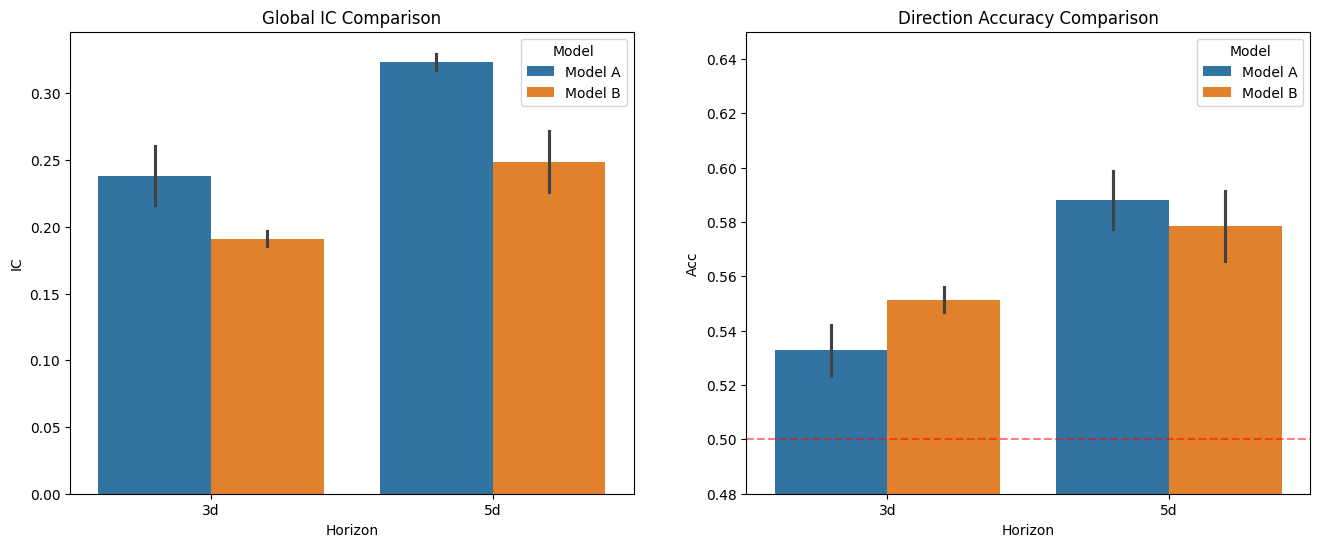

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(ax=axes[0], data=df_comp, x='Horizon', y='IC', hue='Model')
axes[0].set_title('Global IC Comparison')
sns.barplot(ax=axes[1], data=df_comp, x='Horizon', y='Acc', hue='Model')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Direction Accuracy Comparison')
axes[1].set_ylim(0.48, 0.65)
plt.show()